<a href="https://colab.research.google.com/github/farhannewaz-cmd/netflix-viewer-analytics-dashboard/blob/main/Netflix_viewer_engaement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

⏳ Generating mock streaming dataset...
✅ Dataset loaded! Data Shape: (1000, 9)

--- FIRST 5 ROWS OF DATA ---
   User_ID           Timestamp Content_Type   Genre  Duration_Minutes  \
0    59153 2025-04-13 10:00:00        Movie  Sci-Fi               124   
1    43142 2025-12-15 02:00:00        Movie  Sci-Fi               148   
2    36916 2025-09-28 00:00:00        Movie  Comedy                97   
3    74324 2025-04-17 05:00:00      TV Show  Comedy                58   
4    54965 2025-03-13 17:00:00      TV Show  Action               158   

     Device      Month  Hour Day_of_Week  
0  Smart TV      April    10      Sunday  
1    Mobile   December     2      Monday  
2  Smart TV  September     0      Sunday  
3  Smart TV      April     5    Thursday  
4    Mobile      March    17    Thursday  

📈 CALCULATING KEY PERFORMANCE INDICATORS (KPIs)
🎬 Total Content Streamed:  1432.9 Hours
🔥 Most Watched Genre:      Thriller
📺 Most Popular Device:     Smart TV

🎨 Generating Visual Dashboards..

/tmp/ipykernel_437/3976651031.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Genre', order=df['Genre'].value_counts().index, ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_437/3976651031.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=30)
/tmp/ipykernel_437/3976651031.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_minutes, x='Month', y='Duration_Minutes', ax=axes[1, 1], palette='magma')
/tmp/ipykernel_437/3976651031.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ti

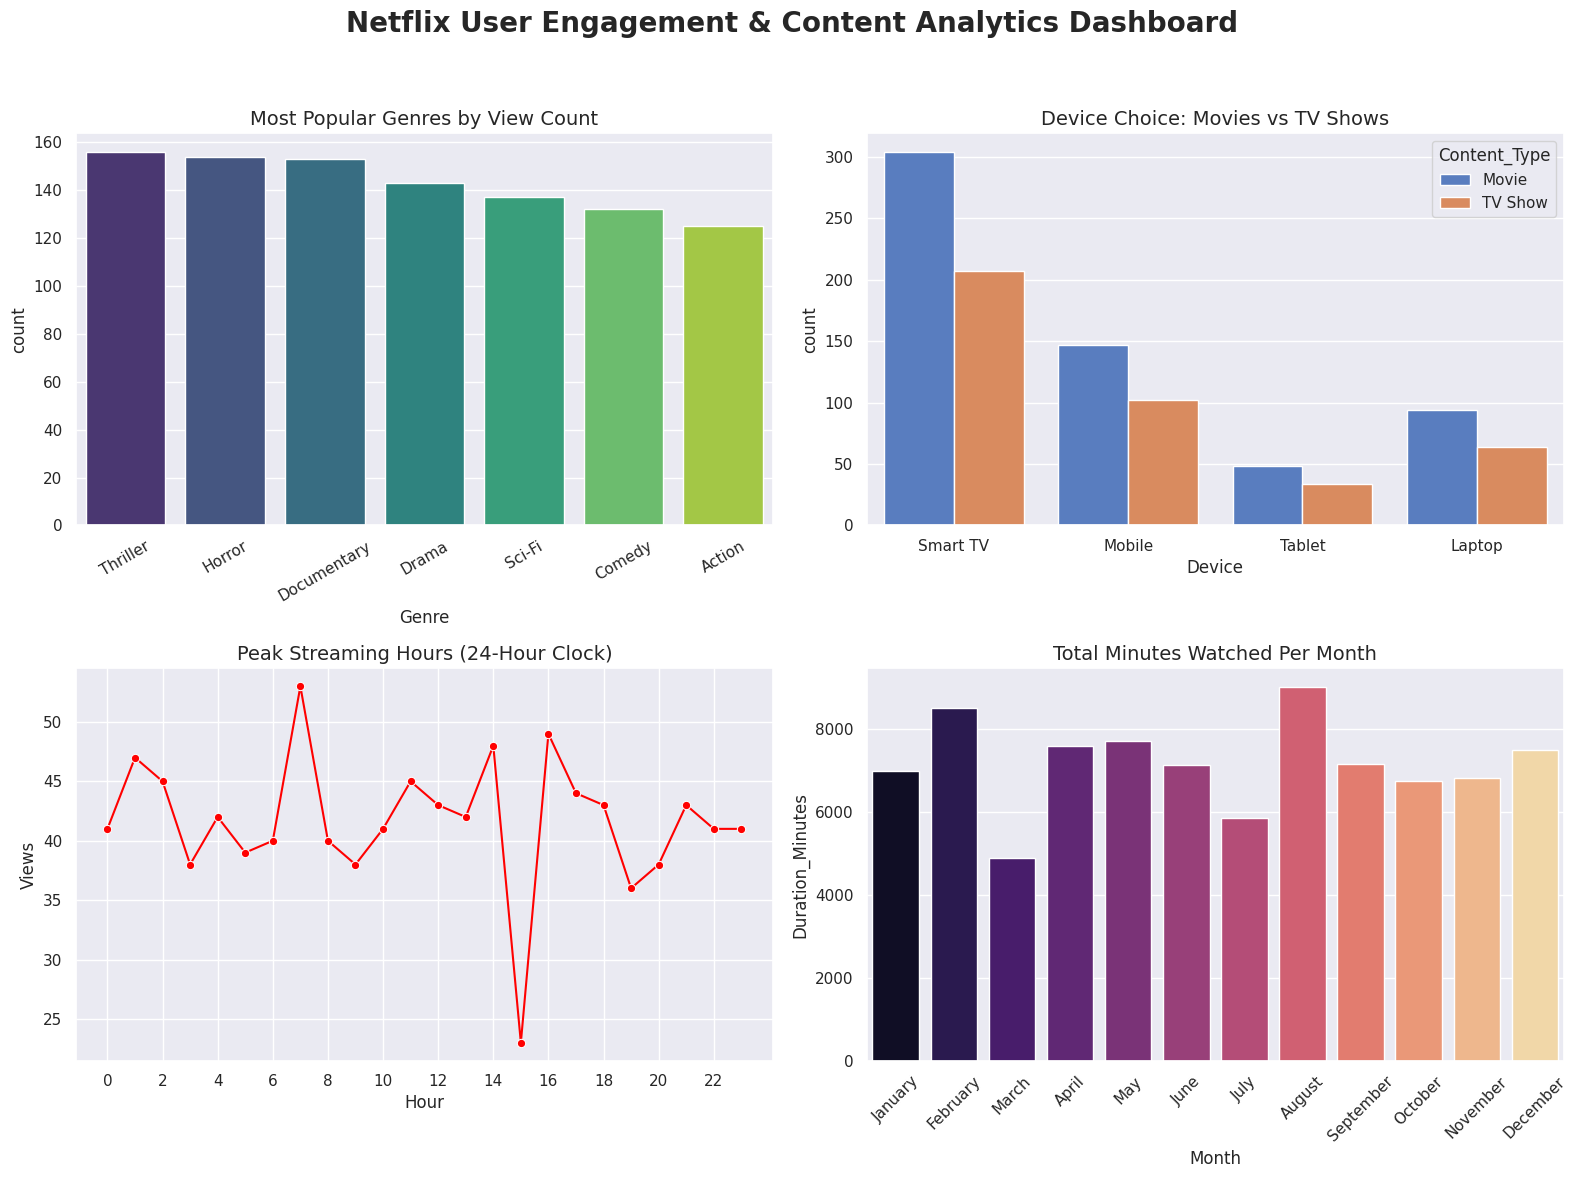

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

# Set a random seed for reproducible "data"
np.random.seed(42)

# ==========================================
# 1. GENERATE SIMULATED NETFLIX DATA
# ==========================================
print("⏳ Generating mock streaming dataset...")

num_records = 1000
genres = ['Sci-Fi', 'Comedy', 'Drama', 'Action', 'Documentary', 'Horror', 'Thriller']
content_types = ['Movie', 'TV Show']
devices = ['Smart TV', 'Mobile', 'Laptop', 'Tablet']

# Generate random timestamps over the last year
start_date = datetime.datetime(2025, 1, 1)
random_days = np.random.randint(0, 365, size=num_records)
timestamps = [start_date + datetime.timedelta(days=int(d), hours=int(np.random.randint(0, 24))) for d in random_days]

data = {
    'User_ID': np.random.randint(10000, 99999, size=num_records),
    'Timestamp': timestamps,
    'Content_Type': np.random.choice(content_types, size=num_records, p=[0.6, 0.4]), # 60% movies
    'Genre': np.random.choice(genres, size=num_records),
    'Duration_Minutes': np.random.randint(10, 160, size=num_records), # watch durations
    'Device': np.random.choice(devices, size=num_records, p=[0.5, 0.25, 0.15, 0.10]) # TV dominant
}

df = pd.DataFrame(data)

# Extract time components for deep analysis
df['Month'] = df['Timestamp'].dt.strftime('%B')
df['Hour'] = df['Timestamp'].dt.hour
df['Day_of_Week'] = df['Timestamp'].dt.strftime('%A')

print("✅ Dataset loaded! Data Shape:", df.shape)
print("\n--- FIRST 5 ROWS OF DATA ---")
print(df.head())

# ==========================================
# 2. DATA ANALYTICS & INSIGHTS
# ==========================================
print("\n" + "="*50)
print("📈 CALCULATING KEY PERFORMANCE INDICATORS (KPIs)")
print("="*50)

total_hours = df['Duration_Minutes'].sum() / 60
most_popular_genre = df['Genre'].value_counts().idxmax()
favorite_device = df['Device'].value_counts().idxmax()

print(f"🎬 Total Content Streamed:  {total_hours:.1f} Hours")
print(f"🔥 Most Watched Genre:      {most_popular_genre}")
print(f"📺 Most Popular Device:     {favorite_device}")

# ==========================================
# 3. DATA VISUALIZATION
# ==========================================
print("\n🎨 Generating Visual Dashboards...")
sns.set_theme(style="darkgrid")

# Create a 2x2 subplot layout for clean metrics distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Netflix User Engagement & Content Analytics Dashboard', fontsize=20, weight='bold')

# Chart 1: Top Genres Breakdown
sns.countplot(data=df, x='Genre', order=df['Genre'].value_counts().index, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Most Popular Genres by View Count', fontsize=14)
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=30)

# Chart 2: Device Preferences by Content Type
sns.countplot(data=df, x='Device', hue='Content_Type', ax=axes[0, 1], palette='muted')
axes[0, 1].set_title('Device Choice: Movies vs TV Shows', fontsize=14)

# Chart 3: Hourly Traffic (When do people watch?)
sns.lineplot(data=df.groupby('Hour').size().reset_index(name='Views'), x='Hour', y='Views', marker='o', color='red', ax=axes[1, 0])
axes[1, 0].set_title('Peak Streaming Hours (24-Hour Clock)', fontsize=14)
axes[1, 0].set_xticks(range(0, 24, 2))

# Chart 4: Monthly Watchtime Volume
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_minutes = df.groupby('Month')['Duration_Minutes'].sum().reindex(month_order).reset_index()
sns.barplot(data=monthly_minutes, x='Month', y='Duration_Minutes', ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Total Minutes Watched Per Month', fontsize=14)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()